In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

employees = pd.read_csv("employees.csv")
attrition = pd.read_csv("attrition_log.csv")
engagement = pd.read_csv("engagement.csv")
performance = pd.read_csv("performance.csv")

att_emp  = pd.merge(employees, attrition, on='employee_id', how='inner')
att_emp

eng_emp = pd.merge(engagement, employees, on='employee_id', how='inner')
eng_emp

perf_emp = pd.merge(performance, employees, on='employee_id', how='inner')
perf_emp

att_eng = pd.merge(attrition, engagement, on='employee_id', how='inner')
att_eng

att_emp_eng = pd.merge(att_emp, engagement, on='employee_id', how='inner')
att_emp_eng

FileNotFoundError: [Errno 2] No such file or directory: 'employees.csv'

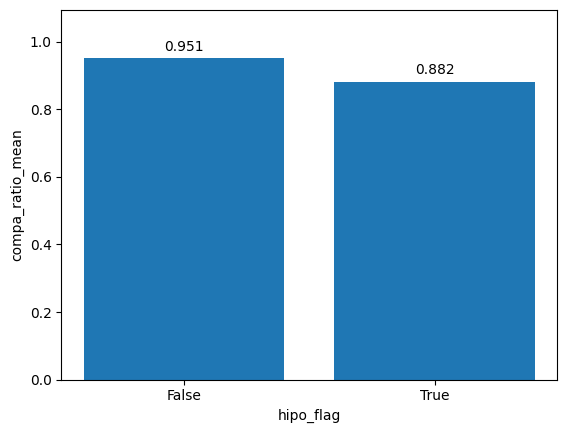

In [9]:
"""
avg(compa_ratio) values for non-hipo and hipo employees
"""
def clean_data(att_emp):
    # Performed 1 aggregation grouped on column: 'hipo_flag'
    att_emp = att_emp.groupby(['hipo_flag']).agg(compa_ratio_mean=('compa_ratio', 'mean')).reset_index()
    return att_emp

hipo_compa = clean_data(att_emp.copy())

plt.figure(figsize=(6, 5))
bar = plt.bar(hipo_compa['hipo_flag'].astype(str), hipo_compa['compa_ratio_mean'])
plt.xlabel('hipo_flag')
plt.ylabel('compa_ratio_mean')
plt.bar_label(bar, fmt='%.3f', padding=3)
plt.ylim(0, max(hipo_compa['compa_ratio_mean']) * 1.15)
plt.show()

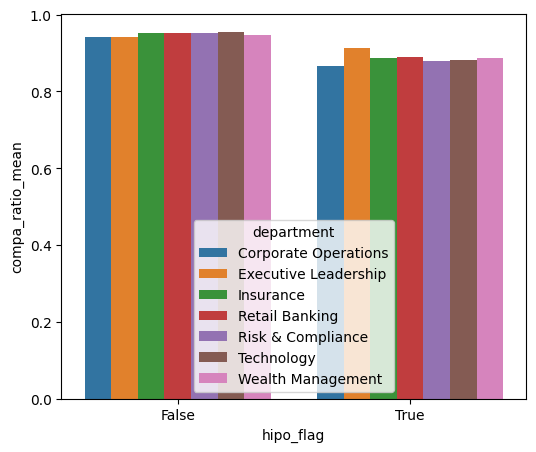

In [10]:
"""
avg(copma_ratio) values for non-hipo and hipo employees by department"""
def clean_data(att_emp):
    # Performed 1 aggregation grouped on columns: 'hipo_flag', 'department'
    att_emp = att_emp.groupby(['hipo_flag', 'department']).agg(compa_ratio_mean=('compa_ratio', 'mean')).reset_index()
    return att_emp

hipo_dept = clean_data(att_emp.copy())

plt.figure(figsize=(6, 5))
sns.barplot(data=hipo_dept, x='hipo_flag', y='compa_ratio_mean', hue='department')
plt.xlabel('hipo_flag')
plt.ylabel('compa_ratio_mean')  
plt.show()

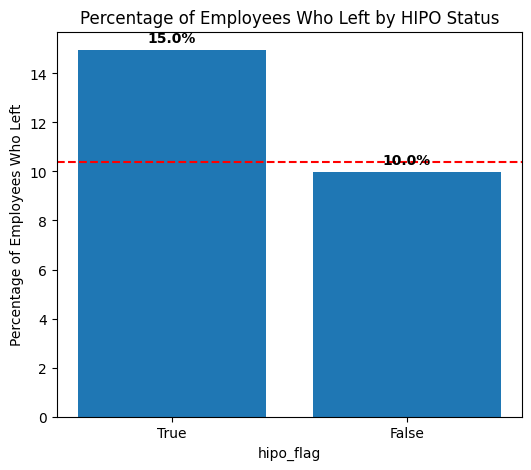

In [13]:
'''
Percentage of Employees Who Left by HIPO Status
'''
total_hipo = (employees['hipo_flag'].astype(str) == 'True').sum()
total_nhipo = (employees['hipo_flag'].astype(str) == 'False').sum()

hipo_left = (att_emp['hipo_flag'].astype(str) == 'True').sum()
nhipo_left = (att_emp['hipo_flag'].astype(str) == 'False').sum()

hipo_left_percentage = (hipo_left / total_hipo) * 100
nhipo_left_percentage = (nhipo_left / total_nhipo) * 100

plt.figure(figsize=(6, 5))
bar = plt.bar(['True', 'False'], [hipo_left_percentage, nhipo_left_percentage])
plt.xlabel('hipo_flag')
plt.ylabel('Percentage of Employees Who Left')
plt.bar_label(bar, fmt='%.1f%%', padding=3, fontweight='bold')
plt.axhline(y=10.4, color='red', linestyle='--', linewidth=1.5, label='Overall attrition rate')
plt.title('Percentage of Employees Who Left by HIPO Status')    
plt.show()


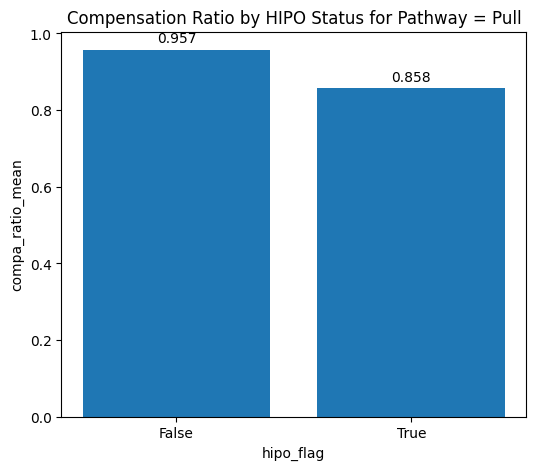

In [25]:
"""
compa_ratio values for non-hipo and hipo employees for pathway = pull
"""
def clean_data(att_emp):
    # Performed 1 aggregation grouped on columns: 'hipo_flag', 'pathway'
    att_emp = att_emp.groupby(['hipo_flag', 'pathway']).agg(compa_ratio_mean=('compa_ratio', 'mean')).reset_index()
    # Filter rows based on column: 'pathway'
    att_emp = att_emp[att_emp['pathway'].str.contains("pull", regex=False, na=False, case=False)]
    return att_emp

hipo_pull = clean_data(att_emp.copy())

plt.figure(figsize=(6, 5))
bar = plt.bar(hipo_pull['hipo_flag'].astype(str), hipo_pull['compa_ratio_mean'])
plt.xlabel('hipo_flag')
plt.ylabel('compa_ratio_mean')
plt.title('Compensation Ratio by HIPO Status for Pathway = Pull')
plt.bar_label(bar, fmt='%.3f', padding=3)
plt.show()

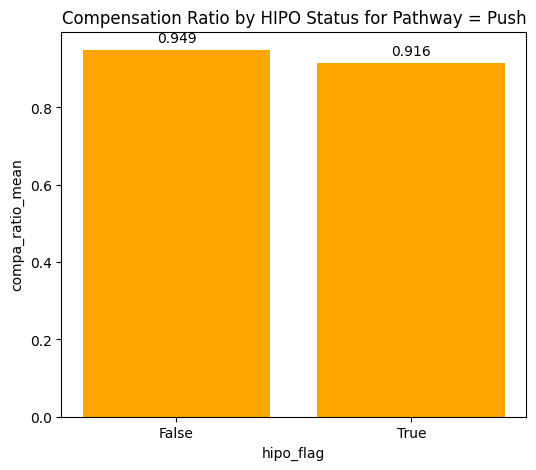

In [5]:
"""
compa_ratio values for non-hipo and hipo employees for pathway = push
"""
def clean_data(att_emp):
    # Performed 1 aggregation grouped on columns: 'hipo_flag', 'pathway'
    att_emp = att_emp.groupby(['hipo_flag', 'pathway']).agg(compa_ratio_mean=('compa_ratio', 'mean')).reset_index()
    # Filter rows based on column: 'pathway'
    att_emp = att_emp[att_emp['pathway'].str.contains("push", regex=False, na=False, case=False)]
    return att_emp

hipo_push = clean_data(att_emp.copy())

plt.figure(figsize=(6, 5))
bar = plt.bar(hipo_push['hipo_flag'].astype(str), hipo_push['compa_ratio_mean'], color='orange')
plt.xlabel('hipo_flag')
plt.ylabel('compa_ratio_mean')
plt.title('Compensation Ratio by HIPO Status for Pathway = Push')
plt.bar_label(bar, fmt='%.3f', padding=3)
plt.show()

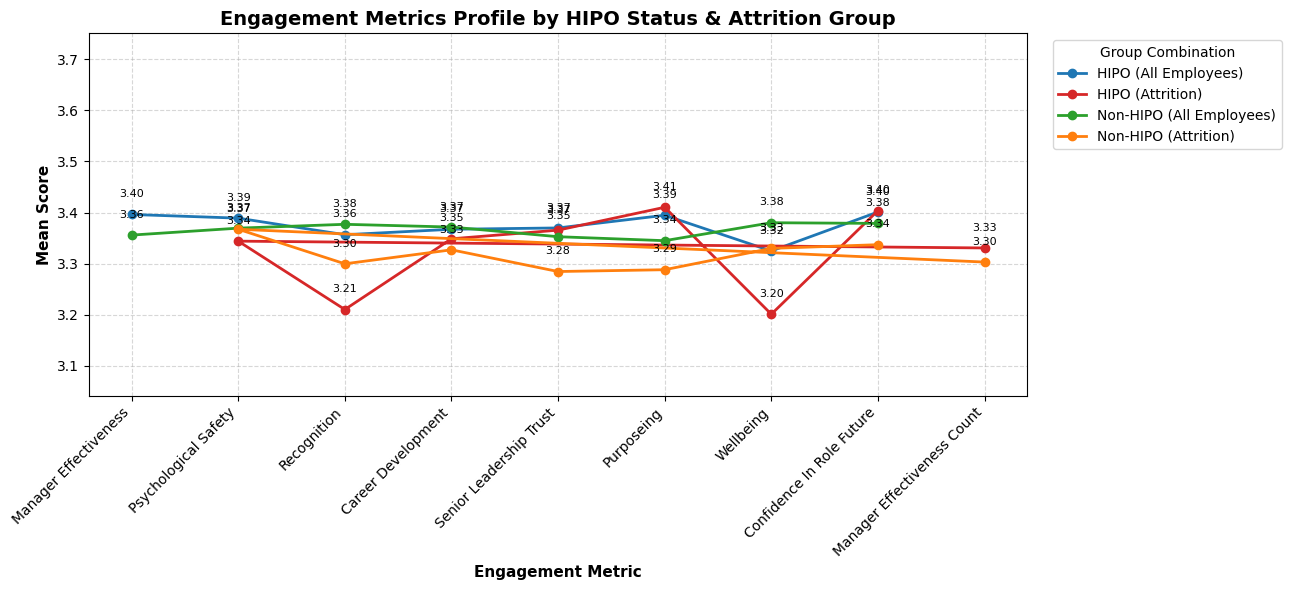

In [ ]:
"""
Engagement Metrics by HIPO Status for Employees in the Attrition Group
"""
def att_data(att_emp_eng):
    # Performed 8 aggregations grouped on column: 'hipo_flag'
    att_emp_eng = att_emp_eng.groupby(['hipo_flag']).agg(manager_effectiveness_count=('manager_effectiveness', 'mean'), psychological_safety_mean=('psychological_safety', 'mean'), recognition_mean=('recognition', 'mean'), career_development_mean=('career_development', 'mean'), senior_leadership_trust_mean=('senior_leadership_trust', 'mean'), purpose_meaning_mean=('purpose_meaning', 'mean'), wellbeing_mean=('wellbeing', 'mean'), confidence_in_role_future_mean=('confidence_in_role_future', 'mean')).reset_index()
    return att_emp_eng

att_hipo = att_data(att_emp_eng.copy())

def emp_data(eng_emp):
    # Performed 8 aggregations grouped on column: 'hipo_flag'
    eng_emp = eng_emp.groupby(['hipo_flag']).agg(manager_effectiveness_mean=('manager_effectiveness', 'mean'), psychological_safety_mean=('psychological_safety', 'mean'), recognition_mean=('recognition', 'mean'), career_development_mean=('career_development', 'mean'), senior_leadership_trust_mean=('senior_leadership_trust', 'mean'), purpose_meaning_mean=('purpose_meaning', 'mean'), wellbeing_mean=('wellbeing', 'mean'), confidence_in_role_future_mean=('confidence_in_role_future', 'mean')).reset_index()
    return eng_emp

emp_hipo = emp_data(eng_emp.copy())

df_att_melted = att_hipo.melt(id_vars=['hipo_flag'], var_name='metric', value_name='mean_value')
df_att_melted['Group'] = 'Attrition'

df_emp_melted = emp_hipo.melt(id_vars=['hipo_flag'], var_name='metric', value_name='mean_value')
df_emp_melted['Group'] = 'All Employees'

# 4. Combine both datasets and clean metric names
df_combined = pd.concat([df_att_melted, df_emp_melted], ignore_index=True)
df_combined['metric'] = df_combined['metric'].str.replace('_mean', '').str.replace('_', ' ').str.title()

# Map HIPO flag into clean labels
df_combined['hipo_label'] = df_combined['hipo_flag'].astype(str).map({
    'True': 'HIPO', 'False': 'Non-HIPO', '1': 'HIPO', '0': 'Non-HIPO'
}).fillna(df_combined['hipo_flag'].astype(str))

# Create the 4 distinct combinations for line plot legend
df_combined['Combination'] = df_combined['hipo_label'] + ' (' + df_combined['Group'] + ')'

# 5. Plot Line Chart
plt.figure(figsize=(13, 6))

# Custom color mapping for the 4 combinations
color_map = {
    'HIPO (Attrition)': '#d62728',      # Red
    'Non-HIPO (Attrition)': '#ff7f0e',  # Orange
    'HIPO (All Employees)': '#1f77b4',  # Blue
    'Non-HIPO (All Employees)': '#2ca02c' # Green
}

# Loop through each combination and draw a line across metrics
for combo, group_df in df_combined.groupby('Combination'):
    plt.plot(
        group_df['metric'], 
        group_df['mean_value'], 
        marker='o', 
        linewidth=2, 
        label=combo,
        color=color_map.get(combo)
    )
    
    # Add exact numerical value labels at data points
    for x, y in zip(group_df['metric'], group_df['mean_value']):
        plt.text(x, y + 0.03, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

# Formatting
plt.title('Engagement Metrics Profile by HIPO Status & Attrition Group', fontsize=14, fontweight='bold')
plt.xlabel('Engagement Metric', fontsize=11, fontweight='bold')
plt.ylabel('Mean Score', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Group Combination', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

# Add top/bottom padding for Y axis so point labels aren't clipped
min_val = df_combined['mean_value'].min() * 0.95
max_val = df_combined['mean_value'].max() * 1.10
plt.ylim(min_val, max_val)

plt.tight_layout()
plt.show()

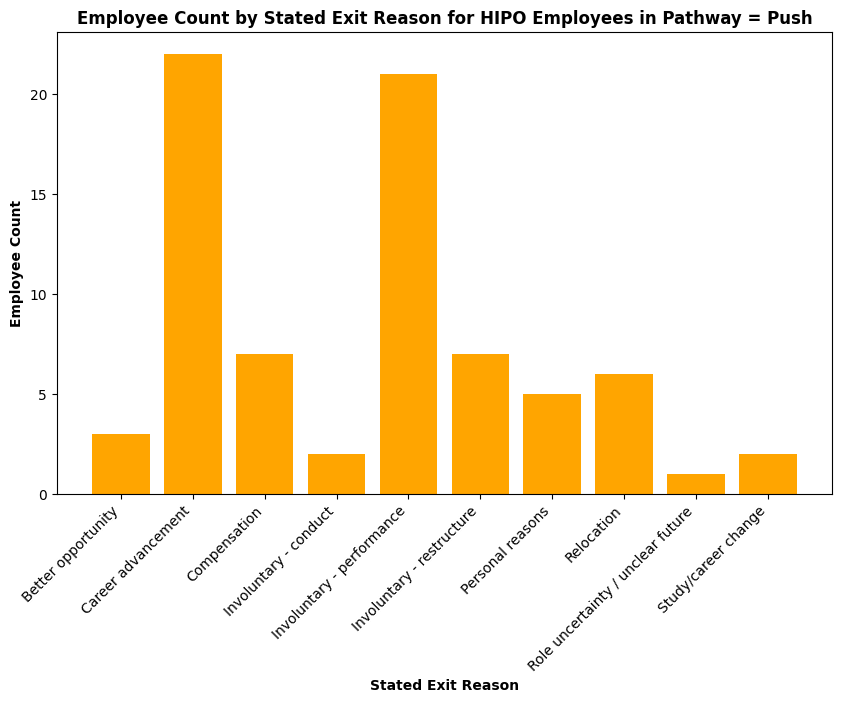

In [7]:
"""
Cell generated by Data Wrangler.
"""
def clean_data(att_emp):
    # Performed 1 aggregation grouped on columns: 'hipo_flag', 'stated_exit_reason', 'pathway'
    att_emp = att_emp.groupby(['hipo_flag', 'stated_exit_reason', 'pathway']).agg(employee_id_count=('employee_id', 'count')).reset_index()
    # Filter rows based on column: 'hipo_flag'
    att_emp = att_emp[att_emp['hipo_flag'].apply(str).str.contains("True", regex=False, na=False, case=False)]
    # Filter rows based on column: 'pathway'
    att_emp = att_emp[att_emp['pathway'].str.contains("push", regex=False, na=False, case=False)]
    return att_emp

hipo_push_exit_reason = clean_data(att_emp.copy())
hipo_push_exit_reason.head()

plt.figure(figsize=(10, 6))
plt.bar(hipo_push_exit_reason['stated_exit_reason'], hipo_push_exit_reason['employee_id_count'],color='orange')
plt.xlabel('Stated Exit Reason', fontweight='bold')
plt.ylabel('Employee Count', fontweight='bold')
plt.title('Employee Count by Stated Exit Reason for HIPO Employees in Pathway = Push', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

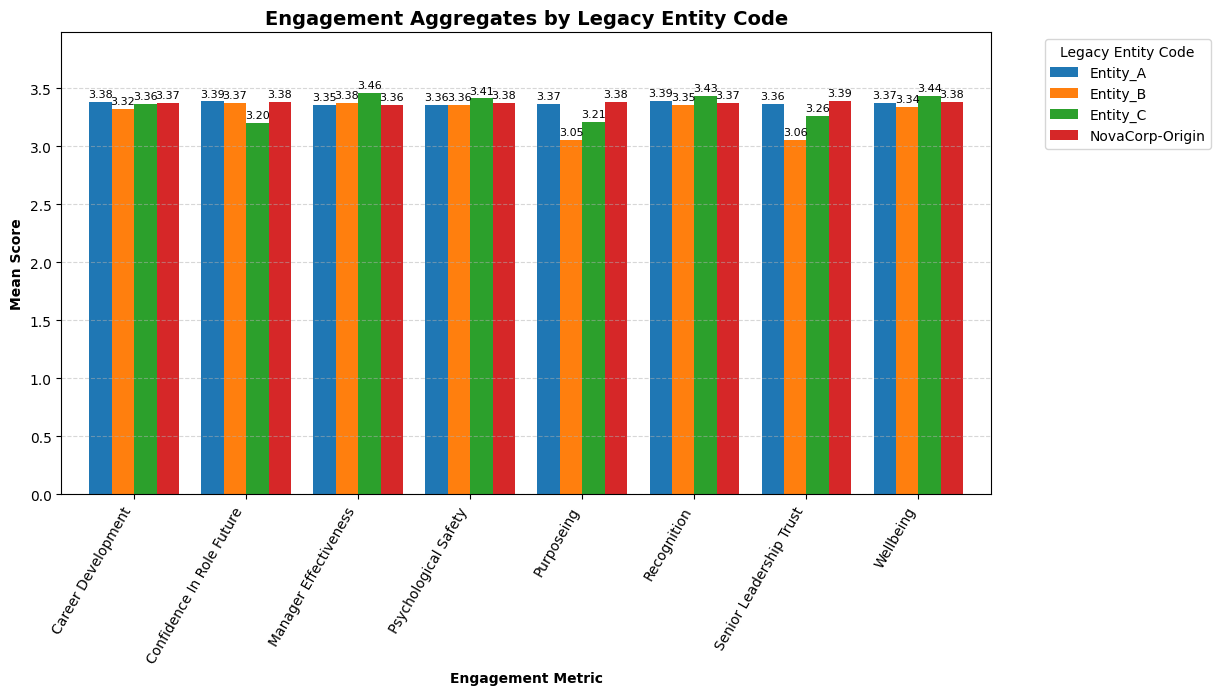

In [11]:
"""
Cell generated by Data Wrangler.
"""
def clean_data(eng_emp):
    # Performed 8 aggregations grouped on column: 'legacy_entity_code'
    eng_emp = eng_emp.groupby(['legacy_entity_code']).agg(
        manager_effectiveness_mean=('manager_effectiveness', 'mean'), 
        psychological_safety_mean=('psychological_safety', 'mean'), 
        recognition_mean=('recognition', 'mean'), 
        career_development_mean=('career_development', 'mean'), 
        senior_leadership_trust_mean=('senior_leadership_trust', 'mean'), 
        purpose_meaning_mean=('purpose_meaning', 'mean'), 
        wellbeing_mean=('wellbeing', 'mean'), 
        confidence_in_role_future_mean=('confidence_in_role_future', 'mean')).reset_index()
    return eng_emp

legacy_engagement = clean_data(eng_emp.copy())

df_melted = legacy_engagement.melt(
    id_vars=['legacy_entity_code'], 
    var_name='metric', 
    value_name='mean_value'
)

df_melted['metric'] = df_melted['metric'].str.replace('_mean', '').str.replace('_', ' ').str.title()
pivot_df = df_melted.pivot(index='metric', columns='legacy_entity_code', values='mean_value')
ax = pivot_df.plot(kind='bar', figsize=(12, 6), width=0.8)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

plt.title('Engagement Aggregates by Legacy Entity Code', fontsize=14, fontweight='bold')
plt.xlabel('Engagement Metric', fontweight='bold')
plt.ylabel('Mean Score', fontweight='bold')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Legacy Entity Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, df_melted['mean_value'].max() * 1.15)
plt.show()

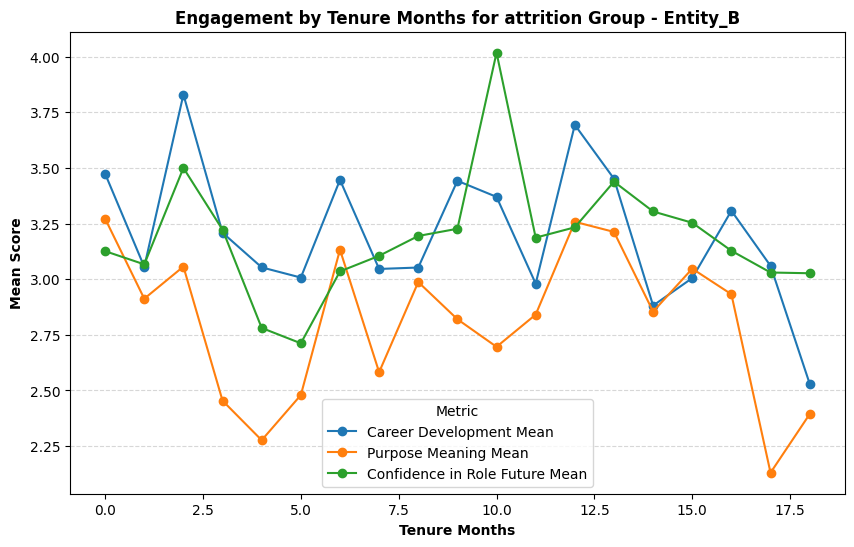

In [12]:
"""
Career Development, Purpose Meaning and Confidence in Role Future by Tenure Months for
employees of Entity_B part of attrition group
"""
def clean_data(att_emp_eng):
    # Performed 2 aggregations grouped on columns: 'legacy_entity_code', 'tenure_months'
    att_emp_eng = att_emp_eng.groupby(['legacy_entity_code', 'tenure_months']).agg(
        career_development_mean=('career_development', 'mean'), 
        purpose_meaning_mean=('purpose_meaning', 'mean'),
        confidence_in_role_future_mean=('confidence_in_role_future', 'mean')).reset_index()
    # Filter rows based on column: 'legacy_entity_code'
    att_emp_eng = att_emp_eng[att_emp_eng['legacy_entity_code'].str.contains("Entity_B", regex=False, na=False, case=False)]
    return att_emp_eng

tenure_eng = clean_data(att_emp_eng.copy())
tenure_eng.head()

plt.figure(figsize=(10, 6))
plt.plot(tenure_eng['tenure_months'], tenure_eng['career_development_mean'], marker='o', label='Career Development Mean')
plt.plot(tenure_eng['tenure_months'], tenure_eng['purpose_meaning_mean'], marker='o', label='Purpose Meaning Mean')
plt.plot(tenure_eng['tenure_months'], tenure_eng['confidence_in_role_future_mean'], marker='o', label='Confidence in Role Future Mean')
plt.xlabel('Tenure Months', fontweight='bold')
plt.ylabel('Mean Score', fontweight='bold')
plt.title('Engagement by Tenure Months for attrition Group - Entity_B', fontweight='bold')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.5)   
plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_29400\2947710298.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_B, x='department', y='pct_leaving', palette='viridis')


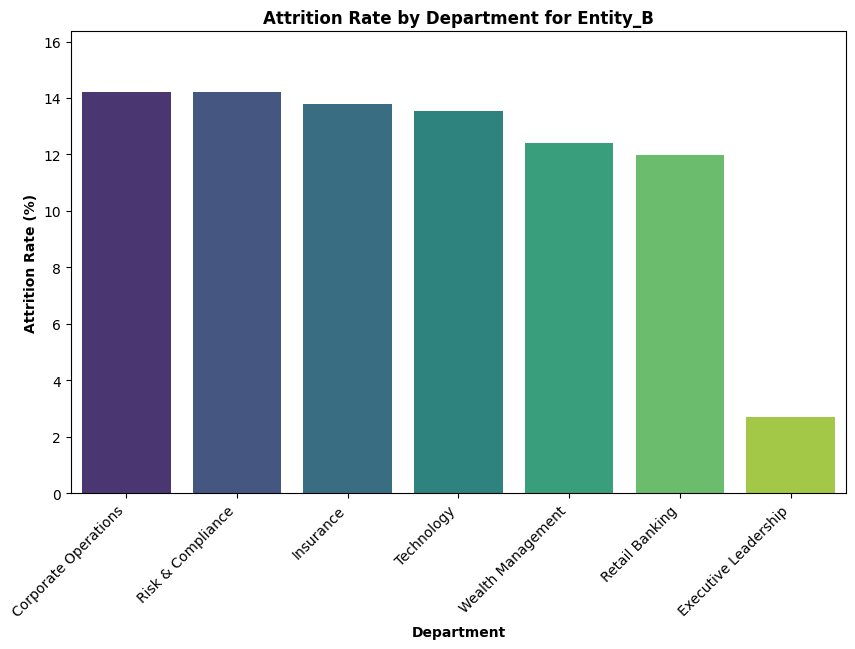

In [19]:
"""
Attrition rate for Entity_B by department
"""
def clean_data(att_emp):
    # Performed 1 aggregation grouped on columns: 'legacy_entity_code', 'department'
    att_emp = att_emp.groupby(['legacy_entity_code', 'department']).agg(employee_id_count=('employee_id', 'count')).reset_index()
    # Filter rows based on column: 'legacy_entity_code'
    att_emp = att_emp[att_emp['legacy_entity_code'].str.contains("Entity_B", regex=False, na=False, case=False)]
    return att_emp

att_B = clean_data(att_emp.copy())
att_B.head()


def clean_data(employees):
    # Performed 1 aggregation grouped on columns: 'department', 'legacy_entity_code'
    employees = employees.groupby(['department', 'legacy_entity_code']).agg(employee_id_count=('employee_id', 'count')).reset_index()
    # Filter rows based on column: 'legacy_entity_code'
    employees = employees[employees['legacy_entity_code'].str.contains("Entity_B", regex=False, na=False, case=False)]
    return employees

emp_B= clean_data(employees.copy())
emp_B.head()

merged_B = att_B.merge(emp_B, on='department', suffixes=('_departed', '_active')
)

merged_B['pct_leaving'] = (merged_B['employee_id_count_departed'] / 
    (merged_B['employee_id_count_departed'] + merged_B['employee_id_count_active'])
) * 100

merged_B = merged_B.sort_values('pct_leaving', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=merged_B, x='department', y='pct_leaving', palette='viridis')
plt.xlabel('Department', fontweight='bold')
plt.ylabel('Attrition Rate (%)', fontweight='bold')
plt.title('Attrition Rate by Department for Entity_B', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, merged_B['pct_leaving'].max() * 1.15)
plt.show()